# Exercise Solutions: Segmentation Using Shallow Learning


1. Load the segmentation mask with the `classifier.model` and filter the segmentation artefacts. Print number of cells before and after cleaning the mask.

In [1]:
import os
import imagej
import scyjava
import imageio
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label
from skimage.io import imsave, imread
from iaf.plot import imshow, show_labels
from iaf.morph.watershed import estimate_object_sizes, separate_neighboring_objects

# Initialize ImageJ with Fiji (can take minutes to initialize) 
ij = imagej.init('sc.fiji:fiji')

Filter segmentation mask

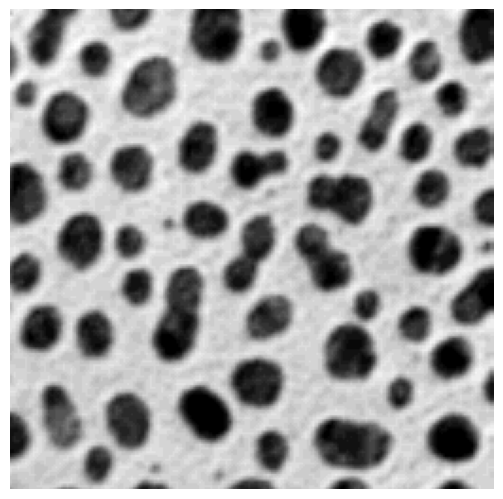

In [30]:
img = imread('illustrations/blobs.gif')
imshow(img[0, :, :, :], auto_stretch=True)

Operating in headless mode - the original ImageJ will have limited functionality.


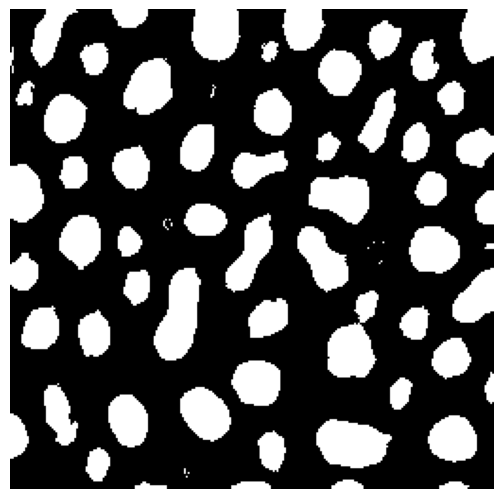

In [4]:
img = ij.io().open('illustrations/blobs.gif')

# Convert to ImagePlus (Java class) for compatibility with WekaSegmentation
imp = ij.py.to_imageplus(img)

# Create WekaSegmentation object with the image
WekaSegmentation = scyjava.jimport('trainableSegmentation.WekaSegmentation')
weka = WekaSegmentation(imp)

# Load pre-trained classifier model (change to your .model file path)
classifier_path = r'illustrations/classifier.model'
weka.loadClassifier(classifier_path)

# Apply the classifier to image, arguments: (ImagePlus, threads=0 auto, getProbabilities=False)
result_imp = weka.applyClassifier(imp, 0, False)

img_py = ij.py.from_java(result_imp)
img_py_n = img_py.to_numpy()
img_py_n_t = img_py_n.transpose(1, 2, 0)
imshow(img_py_n_t, auto_stretch=True)

Found 82 objects.


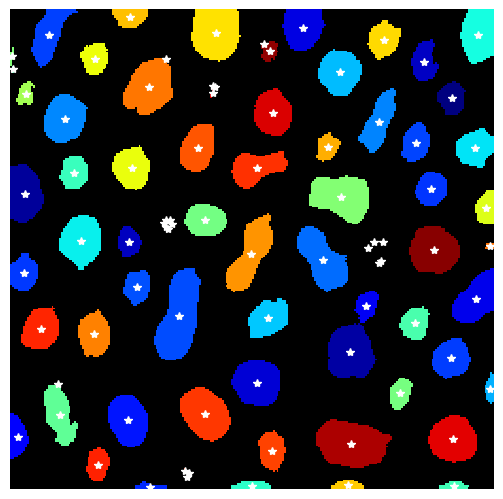

In [15]:
labels, num = label(img_py_n_t[:,:,0], background=0, return_num=True, connectivity=1)
print(f"Found {num} objects.")

show_labels(labels, plot_centroids=True)

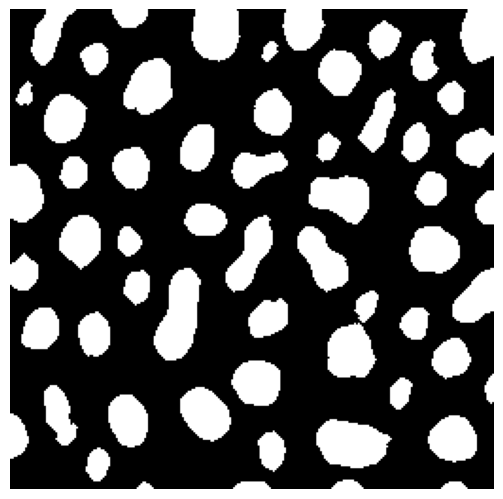

In [10]:
from skimage.morphology import erosion, dilation, disk

# Get rid of artefacts
eroded = erosion(img_py_n_t[:,:,0], disk(2))
# Get back original size
dilated = dilation(eroded, disk(2))
# Sanitiy check
imshow(dilated, auto_stretch=True)

Found 59 objects.


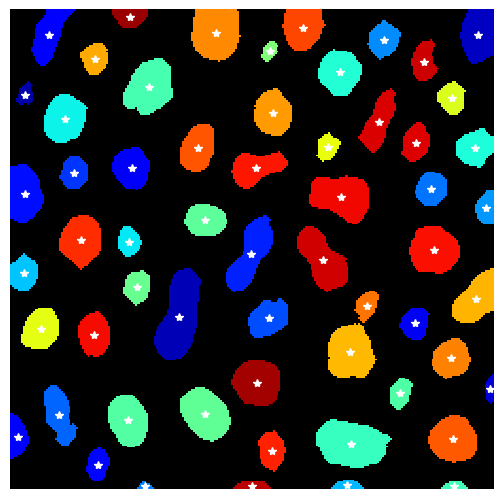

In [16]:
labels_clean, num_clean = label(dilated, background=0, return_num=True, connectivity=1)
print(f"Found {num_clean} objects.")
show_labels(labels_clean, plot_centroids=True)


Removed 23 objects after cleaning. Before: 82. After: 59


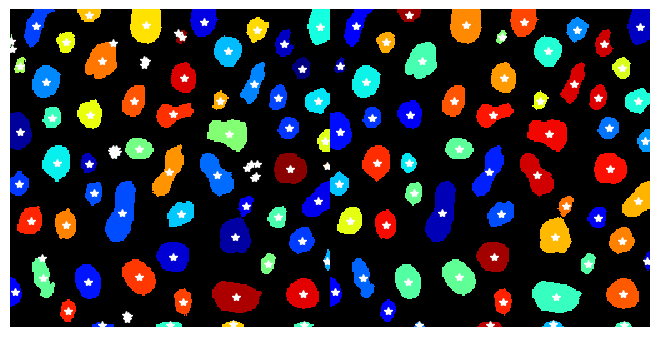

In [25]:
fig, axes = plt.subplots(1, 2)
show_labels(labels, plot_centroids=True, ax=axes[0])
show_labels(labels_clean, plot_centroids=True,  ax=axes[1])

print(f"Removed {num-num_clean} objects after cleaning. Before: {num}. After: {num_clean}")

2. Train a new Weka model in ImageJ/Fiji on the image `cells_shaded.tif` and in python load this new model and compare the segmentation masks to the old model `classifier.model` visually and count the objects.

Comparing two ML models

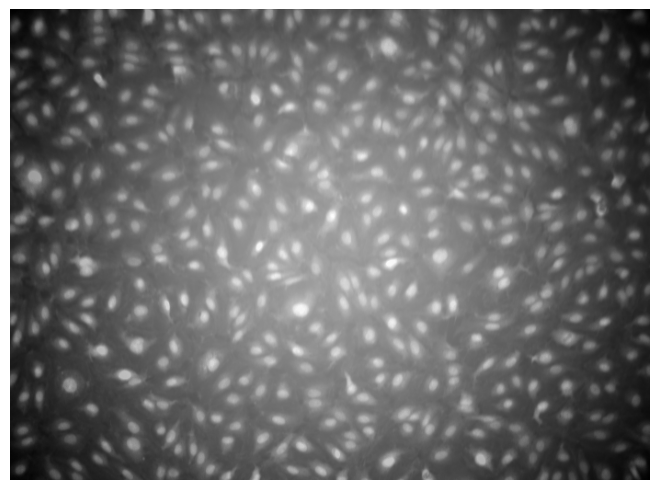

In [32]:
img = imread('illustrations/cells_shaded.tif')
imshow(img, auto_stretch=True)

(512, 696)


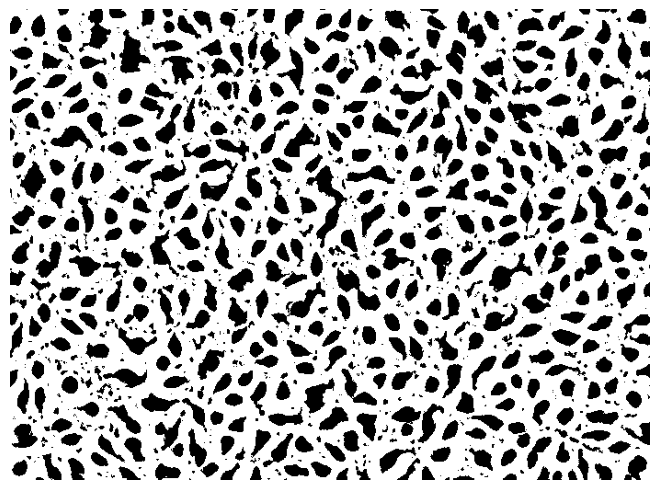

In [68]:
img = ij.io().open('illustrations/cells_shaded.tif')

# Convert to ImagePlus (Java class) for compatibility with WekaSegmentation
imp = ij.py.to_imageplus(img)

# Create WekaSegmentation object with the image
WekaSegmentation = scyjava.jimport('trainableSegmentation.WekaSegmentation')
weka = WekaSegmentation(imp)

# Load pre-trained classifier model (change to your .model file path)
classifier_path = r'illustrations/classifier.model'
weka.loadClassifier(classifier_path)

# Apply the classifier to image, arguments: (ImagePlus, threads=0 auto, getProbabilities=False)
result_imp = weka.applyClassifier(imp, 0, False)

img_py = ij.py.from_java(result_imp)
img_py_n = img_py.to_numpy()
print(img_py_n.shape)
imshow(img_py_n, auto_stretch=True)

Found 1305 objects.


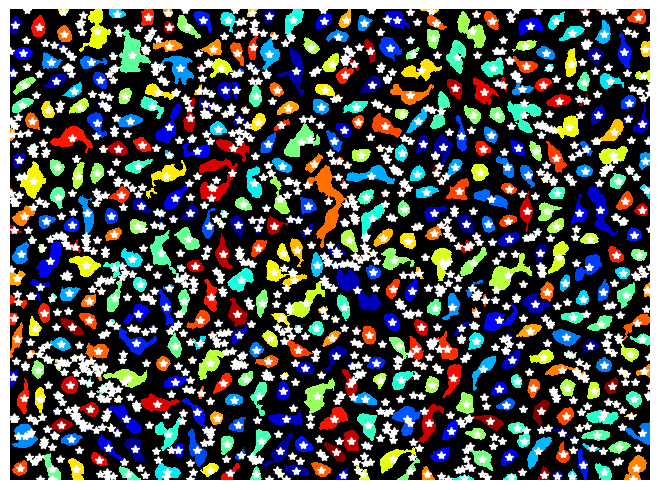

In [69]:
labels, num = label(~img_py_n, background=0, return_num=True, connectivity=1)
print(f"Found {num} objects.")
show_labels(labels, plot_centroids=True)


(512, 696)


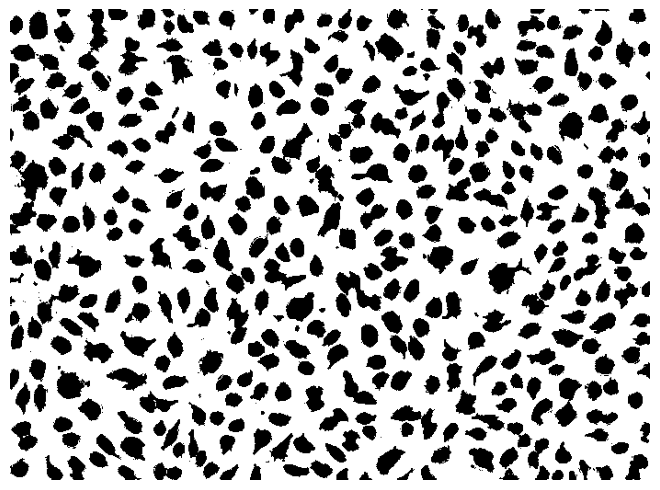

In [65]:
img = ij.io().open('illustrations/cells_shaded.tif')

# Convert to ImagePlus (Java class) for compatibility with WekaSegmentation
imp = ij.py.to_imageplus(img)

# Create WekaSegmentation object with the image
WekaSegmentation = scyjava.jimport('trainableSegmentation.WekaSegmentation')
weka = WekaSegmentation(imp)

# Load pre-trained classifier model (change to your .model file path)
classifier_path = r'illustrations/cells_shaded_classifier.model'
weka.loadClassifier(classifier_path)

# Apply the classifier to image, arguments: (ImagePlus, threads=0 auto, getProbabilities=False)
result_imp = weka.applyClassifier(imp, 0, False)

img_py2 = ij.py.from_java(result_imp)
img_py_n2 = img_py2.to_numpy()
print(img_py_n2.shape)
imshow(img_py_n2, auto_stretch=True)

Found 735 objects.


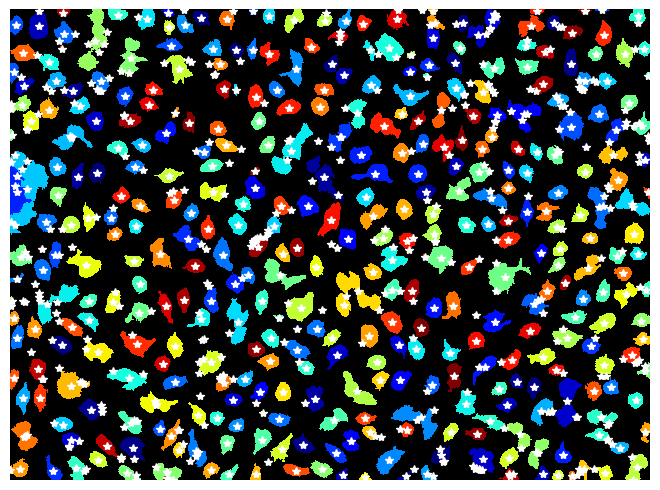

In [66]:
labels_clean2, num_clean2 = label(~img_py_n2, background=0, return_num=True, connectivity=1)
print(f"Found {num_clean2} objects.")
show_labels(labels_clean2, plot_centroids=True)


3. Substract the background first and compare the mask and object count to point 2. 

Try with backgorund substraction first

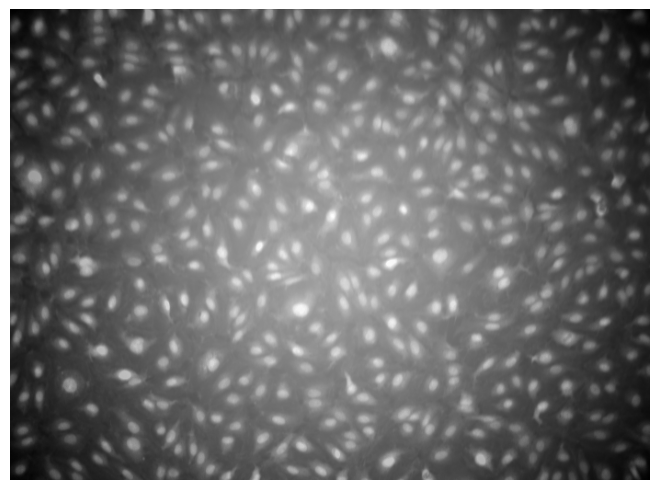

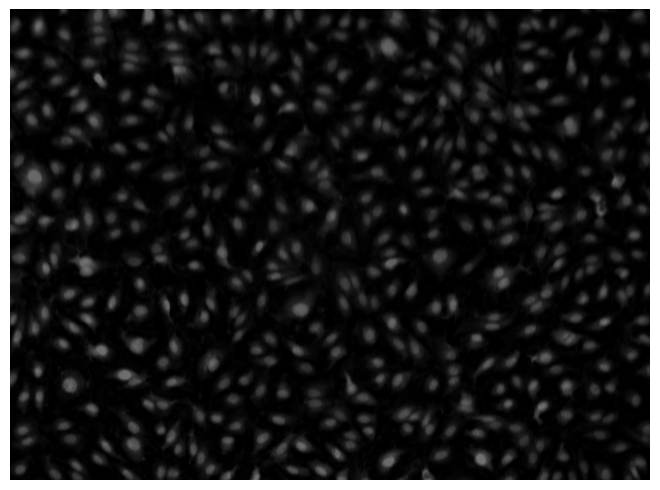

In [48]:
from iaf.plot import imshow, show_labels
from iaf.process import subtract_background

img = imread('illustrations/cells_shaded.tif')
imshow(img, auto_stretch=True)

img_corr, bkg = subtract_background(img, algorithm="morphological_opening", radius=25, return_background=True)
imshow(img_corr)
imsave('illustrations/cells_shaded_bkg_corr.tif', img_corr)

(512, 696)


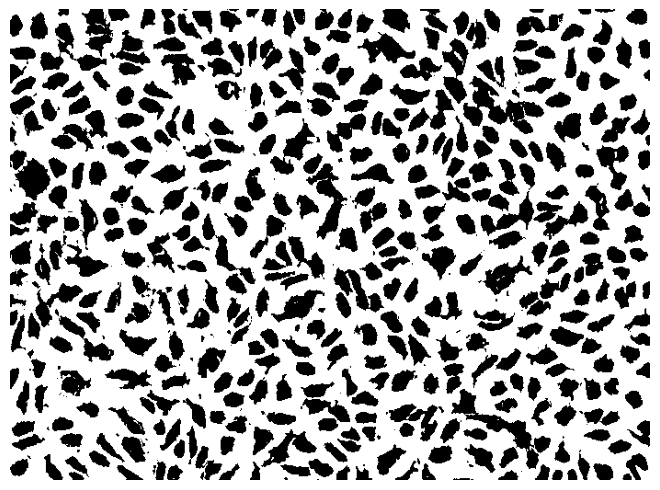

In [62]:
img = ij.io().open('illustrations/cells_shaded_bkg_corr.tif')

# Convert to ImagePlus (Java class) for compatibility with WekaSegmentation
imp = ij.py.to_imageplus(img)

# Create WekaSegmentation object with the image
WekaSegmentation = scyjava.jimport('trainableSegmentation.WekaSegmentation')
weka = WekaSegmentation(imp)

# Load pre-trained classifier model (change to your .model file path)
classifier_path = r'illustrations/cells_shaded_classifier_bkgcorr.model'
weka.loadClassifier(classifier_path)

# Apply the classifier to image, arguments: (ImagePlus, threads=0 auto, getProbabilities=False)
result_imp = weka.applyClassifier(imp, 0, False)

img_py3 = ij.py.from_java(result_imp)
img_py_n3 = img_py3.to_numpy()
print(img_py_n3.shape)
imshow(img_py_n3, auto_stretch=True)

Found 710 objects.


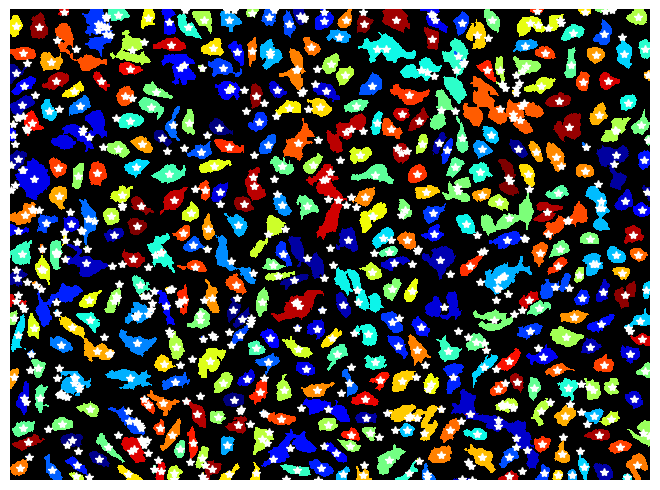

In [63]:
labels_clean3, num_clean3 = label(~img_py_n3, background=0, return_num=True, connectivity=1)
print(f"Found {num_clean3} objects.")
show_labels(labels_clean3, plot_centroids=True)

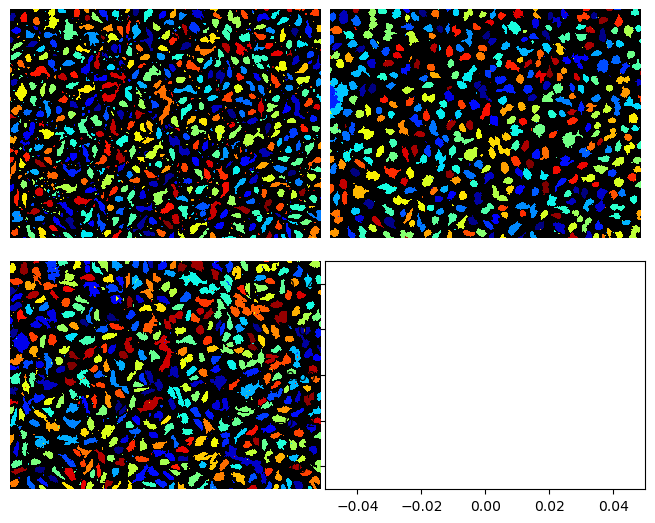

In [72]:
fig, axes = plt.subplots(2, 2)
show_labels(labels, plot_centroids=False, ax=axes[0, 0])
show_labels(labels_clean2, plot_centroids=False,  ax=axes[0, 1])
show_labels(labels_clean3, plot_centroids=False,  ax=axes[1, 0])